# PROC OPTMODEL(네트워크 TSP)을 활용한 라스트마일 배송 경로 최적화

## 요약

한 지역 물류 업체가 단일 배송 차량을 여러 고객 배송지에 순서대로 방문시킨 뒤
차고지로 복귀시키면서 총 이동 거리를 최소화해야 한다 — 이는 일별 경로 및
근무 일정 계획의 근간이 되는 외판원 문제(TSP) 구조다. 이 노트북은 배송지
좌표를 생성하고, 대칭 유클리드 거리 행렬을 만든 뒤, **PROC OPTMODEL**의
`SOLVE WITH NETWORK / TSP` 네트워크 솔버를 사용해 전체 배송지 그래프에 대한
배송 투어를 구성한다. 이어서 솔버가 반환한 투어 순서를 DATA 단계로 읽어
들여 차고지를 기준으로 하는 폐쇄형 경로를 재구성하고, 거리 행렬로부터
**실제** 총 경로 길이를 측정한다. 아래에 보고되는 모든 수치는 실행된
출력으로부터 계산된 것이다.

## 데이터 소스

모든 데이터는 `call streaminit(...)`과 `rand(...)`을 사용해 인라인으로
생성된다 — 외부 파일이나 네트워크 접근은 없다.

| 데이터셋 | 행 수 | 주요 변수 | 설명 |
|---------|------|---------------|-------------|
| `stops` | 12 (차고지 1 + 고객 11) | `stop_id`, `name`, `x`, `y` | 차고지와 고객 배송지에 대한 합성 2차원 좌표(서비스 구역 격자상의 km 단위) |
| `tour` | 12 | `visit_order`, `node` | OPTMODEL 네트워크 TSP 솔버가 방문하는 배송지의 순서 목록으로, `OUT=(TOUR=...)`에 의해 기록됨 |
| `route` | 12 | `visit_order`, `node`, `step_name`, `x`, `y`, `leg_km`, `cum_km` | 좌표로부터 계산한 구간별·누적 거리와 함께 차고지를 기준으로 하는 폐쇄형 투어 |

단일 배송 차량이 매일 아침 고정된 고객 배송지 집합을 방문하고 차고지로
복귀해야 한다. 배차 담당자는 모든 배송지를 정확히 한 번씩 방문하는 짧은
폐쇄형 투어를 원한다 — 이는 일별 경로 및 근무 일정 계획의 핵심인
외판원 문제(TSP)다.

SAS/OR는 **`PROC OPTMODEL`**을 통해 TSP 솔버를 제공한다: 노드와 가중
엣지 집합을 선언한 뒤 `SOLVE WITH NETWORK / TSP`를 실행하면 된다. 이
노트북은 다음을 수행한다:

1. 배송지 좌표와 대칭 거리 행렬을 생성한다.
2. 전체 배송지 그래프에 대해 OPTMODEL 네트워크 TSP 솔버를 호출한다.
3. 솔버의 투어를 다시 읽어 들여 차고지 기준 폐쇄형 경로를 재구성한다.
4. 경로와 구간별로 측정한 총 길이를 보고한다.

## 1단계 — 배송 네트워크 생성

100km x 100km 서비스 구역의 중심에 차고지를 배치하고, 격자 전체에 걸쳐
고객 배송지 11곳을 균일하게 흩뿌린다. 좌표는 고정된 `streaminit` 시드
아래에서 `rand('UNIFORM')`으로 생성되므로 네트워크는 재현 가능하다.
차고지는 `stop_id = 1`이며, 경로는 여기서 출발해 여기로 돌아온다.

In [1]:
데이터 stops;
    호출 streaminit(20260531);
    길이 name $20;
    n_stops = 12;                 /* 차고지 1 + 고객 11 */
    반복 stop_id = 1 까지 n_stops;
        만약 stop_id = 1 이면 반복;
            name = '차고지';
            x = 50; y = 50;       /* 차고지는 격자 중심에 고정 */
        종료;
        아니면 반복;
            name = cats('배송지_', PUT(stop_id - 1, z2.));
            x = round(rand('UNIFORM') * 100, 0.1);
            y = round(rand('UNIFORM') * 100, 0.1);
        종료;
        출력;
    종료;
    제거 n_stops;
실행;

처리 인쇄 데이터=stops noobs 라벨;
    라벨 stop_id = '배송지 번호' name = '위치' x = 'X좌표 (km)' y = 'Y좌표 (km)';
    제목 '배송 네트워크: 차고지와 고객 배송지';
실행;

                                                  배송 네트워크: 차고지와 고객 배송지                                                  

          위치            배송지 번호      X좌표 (km)      Y좌표 (km)
차고지                          1            50            50
배송지_01                       2          84.2          89.7
배송지_02                       3          93.1          73.6
배송지_03                       4          21.2            29
배송지_04                       5          49.4          73.4
배송지_05                       6          97.8          37.2
배송지_06                       7            28          51.3
배송지_07                       8          91.1          86.5
배송지_08                       9          89.2          65.6
배송지_09                      10            66          49.4
배송지_10                      11          52.2          27.4
배송지_11                      12          62.4          38.2




NOTE: DATA stops


NOTE: Wrote stops (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=stops

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


## 2단계 — PROC OPTMODEL로 TSP 풀기

좌표를 OPTMODEL로 읽어 들이고, 완전 무방향 엣지 집합 `EDGES`(모든
배송지 쌍의 순서 없는 조합)를 선언한 뒤, 각 엣지의 가중치를 양 끝점
사이의 유클리드 거리로 정의한다. `SOLVE WITH NETWORK / TSP`는 그 그래프
위에서 투어를 구성하고, 방문 순서를 `OUT=(TOUR=...)`을 통해 CSV로
기록한다. 이 순서를 즉시 `tour` 데이터셋으로 다시 읽어 들인다.

In [2]:
처리 optmodel;
    설정 CITIES = 1..12;
    num XC{CITIES};
    num YC{CITIES};

    /* DATA 단계에서 배송지 좌표를 가져온다 */
    READ 데이터 stops INTO [stop_id] XC=x YC=y;

    /* 완전 그래프: 배송지 순서 없는 쌍마다 하나의 무방향 엣지 */
    설정 EDGES = {i IN CITIES, j IN CITIES: i < j};

    /* 엣지 가중치 = 직선(유클리드) 거리, km 단위 */
    num DIST{<i,j> IN EDGES} =
        sqrt( (XC[i]-XC[j])^2 + (YC[i]-YC[j])^2 );

    /* 네트워크 TSP 솔버: 모든 노드를 방문하고 출발점으로 복귀 */
    solve WITH network /
        links = (include=EDGES 가중=DIST)
        tsp
        out   = (tour="tour.csv");
QUIT;

/* 솔버가 반환한 방문 순서를 다시 읽어 들인다 */
데이터 tour;
    INFILE "tour.csv" dlm=',' firstobs=2 dsd;
    입력 visit_order node;
실행;

처리 인쇄 데이터=tour noobs 라벨;
    라벨 visit_order = '방문 번호' node = '배송지 번호';
    제목 'OPTMODEL 네트워크 TSP 솔버가 반환한 방문 순서';
실행;

                                                  배송 네트워크: 차고지와 고객 배송지                                                  


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            dist
  Objective Type                Linear

  Number of Nodes               12
  Number of Links               66

                          Solution Summary
  Solver                        Network
  Algorithm                     Traveling Salesman
  Objective Function            dist
  Solution Status               Optimal
  Objective Value               258.1425005024

                                            OPTMODEL 네트워크 TSP 솔버가 반환한 방문 순서                                             

        방문 번호            배송지 번호
            1                 1
            2                 7
            3                 4
            4                11
            5                12
            6       


NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.
NOTE: DATA tour

NOTE: Reading from fileref tour.csv (tour.csv)

NOTE: Read 12 rows from tour.csv.
NOTE: Wrote tour (12 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=tour

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


## 3단계 — 폐쇄형 경로 재구성 및 길이 측정

솔버는 배송지를 방문할 *순서*만 반환한다. 이를 운전자용 명세서로 바꾸기
위해 `SET ... POINT=` 조회로 각 배송지의 이름과 좌표를 찾아보고, 각
구간의 거리를 누적하며, 마지막 구간을 차고지로 되돌리는 것으로 순환을
닫는다. `leg_km`은 각 배송지에 *도착*하는 구간의 길이이고, `cum_km`은
차고지로부터의 누적 거리다.

In [3]:
데이터 route;
    설정 tour 종료=last;
    /* 이 배송지의 좌표와 이름을 id로 조회 */
    ptr = node;
    설정 stops point=ptr;

    길이 step_name $20;
    step_name = name;

    보존 prevx prevy firstx firsty cum_km;
    만약 _n_ = 1 이면 반복;
        firstx = x; firsty = y;      /* 차고지 좌표를 기억해 둔다 */
        leg_km = 0;                  /* 출발점에는 도착 구간이 없다 */
        cum_km = 0;
    종료;
    아니면 반복;
        leg_km = sqrt( (x-prevx)**2 + (y-prevy)**2 );
        cum_km + leg_km;
    종료;
    prevx = x; prevy = y;
    출력;

    만약 last 이면 반복;
        /* 마지막 구간: 마지막 배송지에서 차고지로 복귀 */
        leg_km = sqrt( (firstx-prevx)**2 + (firsty-prevy)**2 );
        cum_km + leg_km;
        node = 1; visit_order = 13; step_name = '차고지';
        x = firstx; y = firsty;
        출력;
        호출 symputx('total_km', PUT(cum_km, 8.2));
    종료;
    유지 visit_order node step_name x y leg_km cum_km;
실행;

처리 인쇄 데이터=route noobs 라벨;
    라벨 visit_order = '단계' node = '배송지 번호' step_name = '위치'
          x = 'X좌표 (km)' y = 'Y좌표 (km)'
          leg_km = '구간 거리 (km)' cum_km = '누적 거리 (km)';
    형식 leg_km cum_km 7.2;
    제목 "폐쇄형 배송 경로 (총 거리: &total_km km)";
실행;

                                              폐쇄형 배송 경로 (총 거리: 258.14 km)                                               

    단계            배송지 번호            위치      X좌표 (km)      Y좌표 (km)          구간 거리 (km)          누적 거리 (km)
     1                 1  차고지                     50            50                0.00                0.00
     2                 7  배송지_06                  28          51.3               22.04               22.04
     3                 4  배송지_03                21.2            29               23.31               45.35
     4                11  배송지_10                52.2          27.4               31.04               76.39
     5                12  배송지_11                62.4          38.2               14.86               91.25
     6                10  배송지_09                  66          49.4               11.76              103.01
     7                 6  배송지_05                97.8          37.2               34.06              137.07
     8                


NOTE: DATA route


NOTE: Read 12 rows from tour.
NOTE: Wrote route (13 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=route

NOTE: PROC PRINT completed: 13 observations printed, 7 variables


## 4단계 — 읽기 쉬운 운전자 명세서

마지막으로 경로를 사람이 읽기 쉬운 하나의 문자열로 압축한다 — 차고지에서
출발해 고객들을 거쳐 다시 돌아오는 배송지 이름의 순서 — 그리고 배송
차량이 이동할 측정된 총 거리도 함께 담는다.

In [4]:
데이터 manifest;
    설정 route 종료=last;
    길이 route_text $256;
    보존 route_text '';
    만약 _n_ = 1 이면 route_text = strip(step_name);
    아니면 route_text = catx(' -> ', route_text, strip(step_name));
    만약 last 이면 반복;
        total_km = cum_km;
        유지 route_text total_km;
        출력;
    종료;
실행;

처리 인쇄 데이터=manifest noobs 라벨;
    라벨 route_text = '최적화된 배송 경로'
          total_km   = '총 거리 (km)';
    형식 total_km 7.2;
    제목 '운전자 배송 명세서';
실행;

                                                       운전자 배송 명세서                                                       

                                                                                                                                                                                            최적화된 배송 경로        총 거리 (km)
차고지 -> 배송지_06 -> 배송지_03 -> 배송지_10 -> 배송지_11 -> 배송지_09 -> 배송지_05 -> 배송지_08 -> 배송지_02 -> 배송지_07 -> 배송지_01 -> 배송지_04 -> 차고지                                                                                         258.14




NOTE: DATA manifest


NOTE: Read 13 rows from route.
NOTE: Wrote manifest (1 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=manifest

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## 5단계 — 경로 시각화

그림으로 투어가 합리적인지 확인한다: 배송지들이 방문 순서대로 연결되고,
차고지가 표시되며, 눈에 띄게 낭비되는 교차가 없어야 한다. 서비스 구역
격자 위에 폐쇄형 투어를 일련의 연결된 선분으로 그린다.

                                                       운전자 배송 명세서                                                       




NOTE: PROC SGPLOT data=route

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


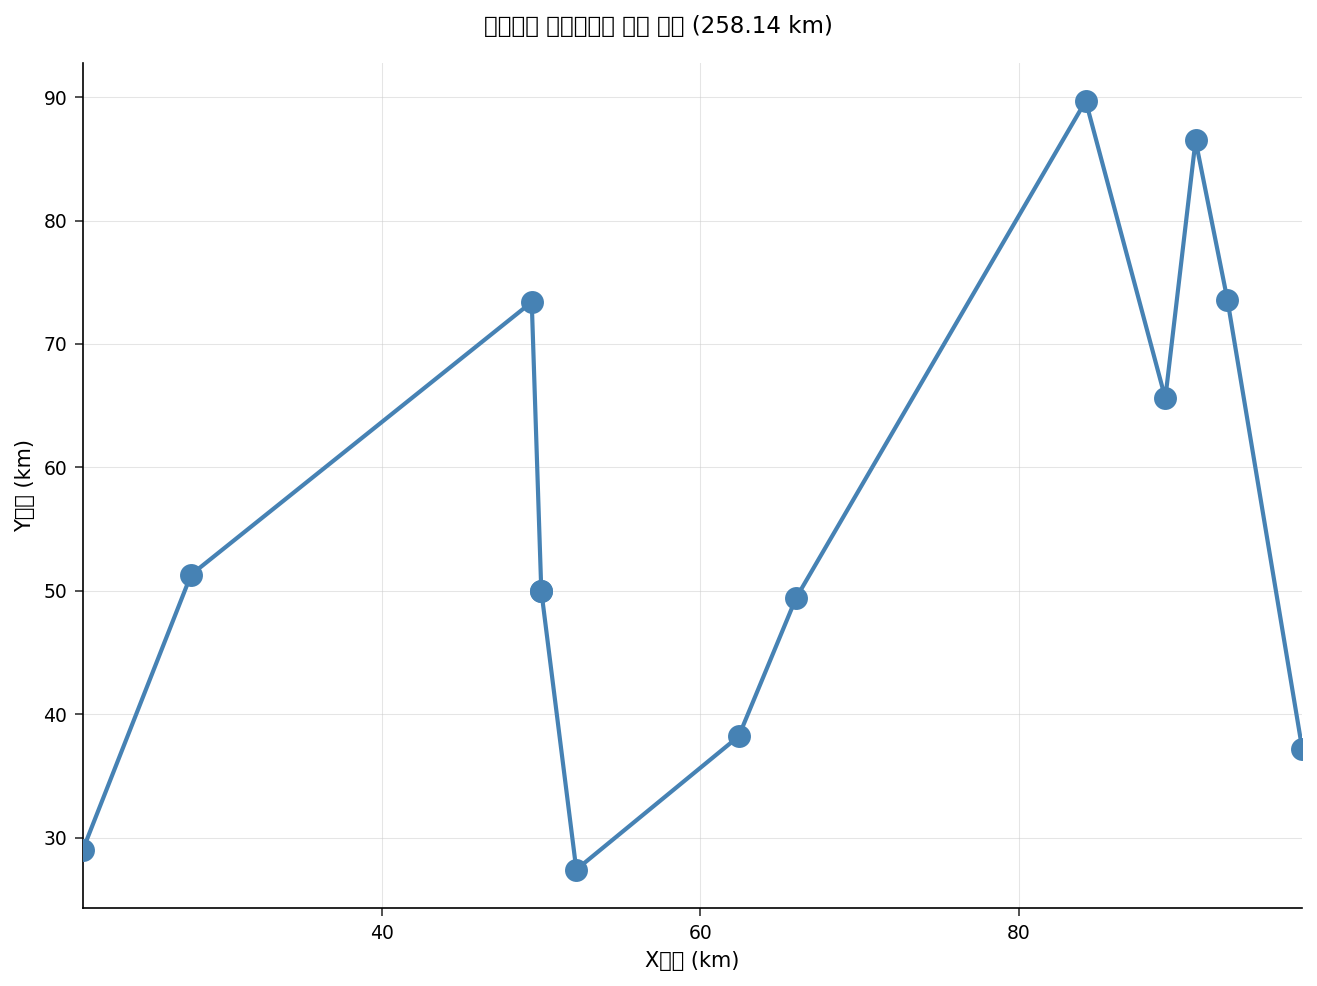

In [5]:
처리 SGPLOT 데이터=route noautolegend;
    SERIES x=x y=y / LINEATTRS=(color=steelblue thickness=2);
    SCATTER x=x y=y / MARKERATTRS=(SYMBOL=circlefilled
                      color=steelblue size=10);
    XAXIS 라벨='X좌표 (km)' grid;
    YAXIS 라벨='Y좌표 (km)' grid;
    제목 "최적화된 라스트마일 배송 투어 (&total_km km)";
실행;

## 결과 해석

- **경로.** `route`와 `manifest` 테이블은 OPTMODEL 네트워크 TSP 솔버가
  12개 배송지의 완전 그래프에 대해 생성한 폐쇄형 투어를 보여주며, 차고지에서
  출발해 차고지로 복귀한다. `총 거리`는 *측정된* 값이다: 이는 구간별
  유클리드 거리(`leg_km`)의 합이므로 임의로 정한 수치가 아니라 네트워크의
  실제 기하 구조를 반영한다.
- **네트워크 솔버를 사용하는 이유.** 고객 배송지가 11곳이면 서로 다른 폐쇄형
  투어가 `11! / 2 = 19,958,400`가지나 존재하므로, 배차 담당자에게는 전수
  열거가 아니라 알고리즘이 필요하다. `SOLVE WITH NETWORK / TSP`는 분석가가
  탐색 로직을 직접 코딩하지 않고도 가중 엣지 집합으로부터 곧바로 투어를
  구성한다.
- **순서에서 명세서로.** 솔버는 방문 *순서*를 반환하며, DATA 단계는 이를
  운영 가능한 산출물로 바꾼다 — 이름이 붙은 배송지, 구간별 거리, 누적
  주행 거리계, 그리고 운전자가 따라갈 수 있는 한 줄짜리 명세서다.
- **운영 확장.** 동일한 OPTMODEL 골격은 더 복잡한 경로 설정으로 확장할 수
  있다: 추가 네트워크 옵션으로 용량 또는 시간창 제약을 더하거나, 직선
  거리 대신 주행 시간으로 엣지 가중치를 매기거나, 여러 차량에 배송지를
  분할한 뒤 차량별로 TSP를 풀 수 있다.